# 01 - Data Cleaning & Exploratory Data Analysis

**CSCI 567 Final Project: Weekly Gasoline Price Forecasting**

This notebook covers:
1. Loading and inspecting the raw EIA gasoline price dataset
2. Data cleaning
3. Exploratory visualizations (price trends, distributions, volatility)
4. Feature engineering
5. Train / Validation / Test split
6. Saving cleaned data for downstream modeling

---
## 1. Setup & Load Data

In [1]:
import sys
import os

# Allow imports from the project src/ directory
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import data_utils
import evaluate

# Plot styling
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

%matplotlib inline

In [2]:
# Load the raw dataset
df_raw = data_utils.load_raw_data()
print(f"Loaded {len(df_raw)} rows and {len(df_raw.columns)} columns.")

Loaded 1361 rows and 14 columns.


---
## 2. Raw Data Exploration

In [3]:
df_raw.head(10)

,Date,A1,A2,A3,R1,R2,R3,M1,M2,M3,P1,P2,P3,D1
0,1995-01-02,1.127,1.104,1.231,1.079,1.063,1.167,1.170,1.159,1.298,1.272,1.250,1.386,1.104
1,1995-01-09,1.134,1.111,1.232,1.086,1.070,1.169,1.177,1.164,1.300,1.279,1.256,1.387,1.102
2,1995-01-16,1.126,1.102,1.231,1.078,1.062,1.169,1.168,1.155,1.299,1.271,1.249,1.385,1.100
3,1995-01-23,1.132,1.110,1.226,1.083,1.068,1.165,1.177,1.165,1.296,1.277,1.256,1.378,1.095
4,1995-01-30,1.131,1.109,1.221,1.083,1.068,1.162,1.176,1.163,1.291,1.275,1.255,1.370,1.090
5,1995-02-06,1.124,1.103,1.218,1.076,1.062,1.159,1.169,1.157,1.288,1.270,1.250,1.368,1.086
6,1995-02-13,1.121,1.099,1.218,1.074,1.058,1.158,1.166,1.153,1.285,1.265,1.243,1.367,1.088
7,1995-02-20,1.115,1.093,1.213,1.067,1.052,1.153,1.160,1.148,1.280,1.259,1.239,1.363,1.088
8,1995-02-27,1.121,1.101,1.211,1.073,1.060,1.152,1.164,1.153,1.276,1.265,1.246,1.362,1.089
9,1995-03-06,1.123,1.103,1.209,1.076,1.063,1.149,1.167,1.157,1.275,1.263,1.244,1.358,1.089


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1361 entries, 0 to 1360
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1361 non-null   datetime64[us]
 1   A1      1361 non-null   float64       
 2   A2      1361 non-null   float64       
 3   A3      1361 non-null   float64       
 4   R1      1361 non-null   float64       
 5   R2      1361 non-null   float64       
 6   R3      1361 non-null   float64       
 7   M1      1361 non-null   float64       
 8   M2      1361 non-null   float64       
 9   M3      1361 non-null   float64       
 10  P1      1361 non-null   float64       
 11  P2      1361 non-null   float64       
 12  P3      1361 non-null   float64       
 13  D1      1361 non-null   float64       
dtypes: datetime64[us](1), float64(13)
memory usage: 149.0 KB


In [5]:
df_raw.describe()

,Date,A1,A2,A3,R1,R2,R3,M1,M2,M3,P1,P2,P3,D1
count,1361,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000
mean,2008-01-14 00:00:00,2.285680,2.234511,2.396873,2.225170,2.178511,2.329126,2.382822,2.320970,2.508877,2.519840,2.472096,2.609244,2.404699
min,1995-01-02 00:00:00,0.949000,0.926000,1.039000,0.907000,0.885000,0.974000,1.008000,0.979000,1.112000,1.100000,1.074000,1.191000,0.953000
25%,2001-07-09 00:00:00,1.461000,1.433000,1.550000,1.421000,1.393000,1.489000,1.517000,1.482000,1.616000,1.607000,1.573000,1.695000,1.418000
50%,2008-01-14 00:00:00,2.326000,2.251000,2.458000,2.237000,2.175000,2.367000,2.481000,2.404000,2.627000,2.693000,2.640000,2.769000,2.479000
75%,2014-07-21 00:00:00,2.903000,2.825000,3.060000,2.828000,2.765000,2.976000,3.033000,2.930000,3.206000,3.209000,3.127000,3.318000,3.070000
max,2021-01-25 00:00:00,4.165000,4.102000,4.301000,4.114000,4.054000,4.247000,4.229000,4.153000,4.387000,4.344000,4.283000,4.459000,4.764000
std,NaN,0.859028,0.843815,0.883311,0.850143,0.835549,0.876739,0.882107,0.858521,0.908861,0.911055,0.894472,0.925587,0.998646


In [6]:
# Missing values summary
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")
print(f"\nTotal missing cells: {df_raw.isnull().sum().sum()}")

Missing values per column:
No missing values found.

Total missing cells: 0


In [7]:
# Date range and record count
print(f"Date range : {df_raw['Date'].min().strftime('%Y-%m-%d')}  to  {df_raw['Date'].max().strftime('%Y-%m-%d')}")
print(f"Number of records : {len(df_raw)}")
print(f"Number of years   : {df_raw['Date'].dt.year.nunique()}")

Date range : 1995-01-02  to  2021-01-25
Number of records : 1361
Number of years   : 27


---
## 3. Data Cleaning

In [8]:
df = data_utils.clean_data(df_raw.copy())

# Verify no remaining missing values
remaining_missing = df.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")
assert remaining_missing == 0, "There are still missing values!"
print("Data cleaning complete. All columns are numeric with no gaps.")

Missing values after cleaning: 0
Data cleaning complete. All columns are numeric with no gaps.


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 All Grades Price (A1) Over Time

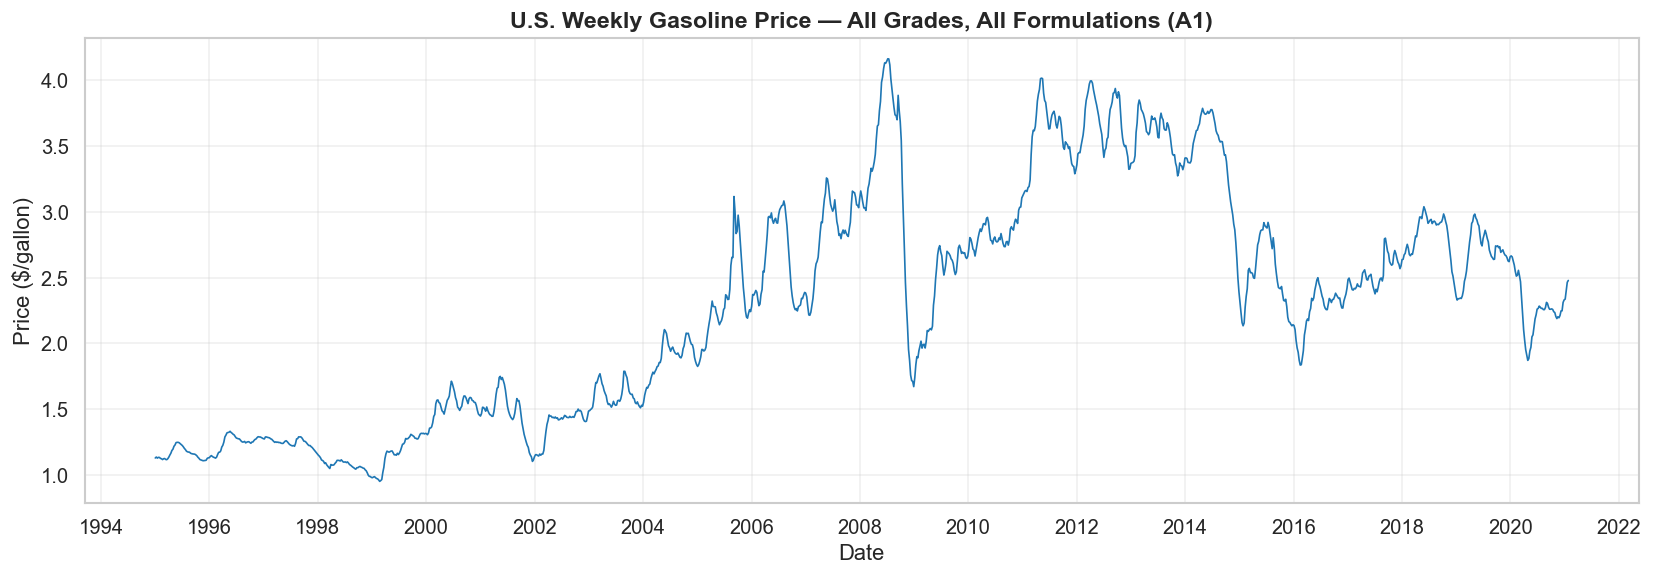

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['A1'], color='#1f77b4', linewidth=1.0)
ax.set_title('U.S. Weekly Gasoline Price — All Grades, All Formulations (A1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 All Fuel Grade Types Compared

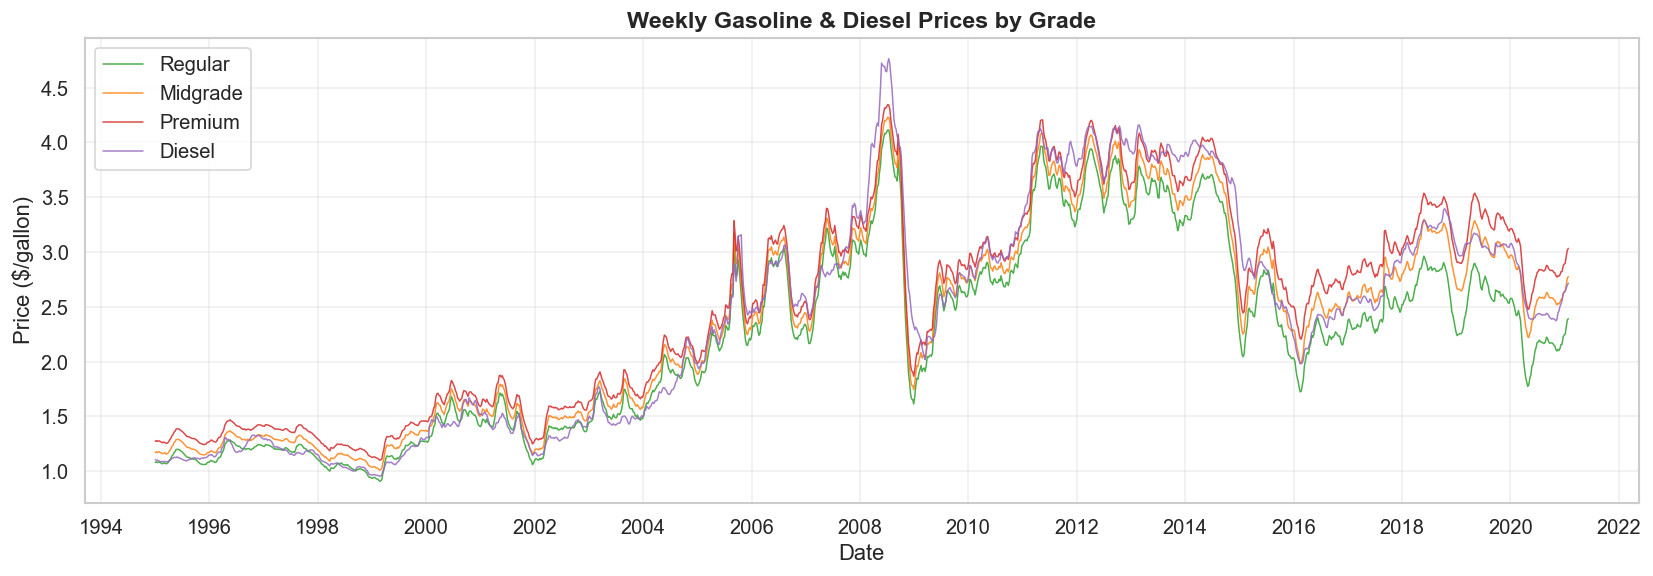

In [10]:
grade_cols = {'R1': 'Regular', 'M1': 'Midgrade', 'P1': 'Premium', 'D1': 'Diesel'}
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(14, 5))
for (col, label), color in zip(grade_cols.items(), colors):
    ax.plot(df['Date'], df[col], label=label, linewidth=0.9, color=color, alpha=0.85)

ax.set_title('Weekly Gasoline & Diesel Prices by Grade', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.legend(loc='upper left', frameon=True)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Distribution of A1 Prices

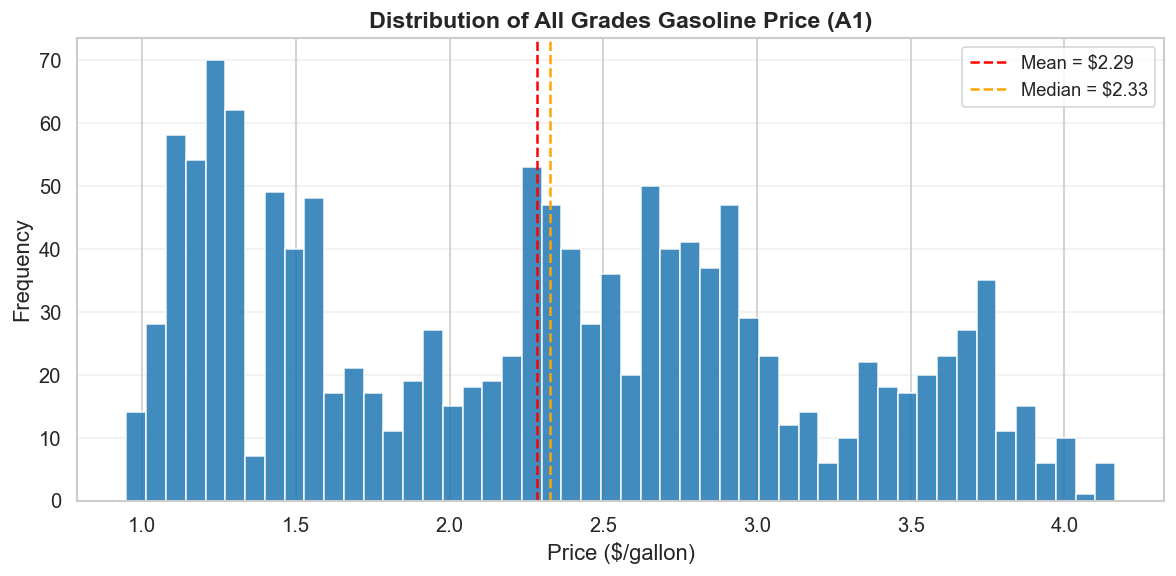

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['A1'], bins=50, color='#1f77b4', edgecolor='white', alpha=0.85)
ax.axvline(df['A1'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean = ${df['A1'].mean():.2f}")
ax.axvline(df['A1'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median = ${df['A1'].median():.2f}")
ax.set_title('Distribution of All Grades Gasoline Price (A1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price ($/gallon)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4.4 Year-over-Year Price Comparison (Box Plot)

/var/folders/7m/_5b8_7b94dl_t506bh8l_zj40000gn/T/ipykernel_20874/1344416477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Year', y='A1', ax=ax, palette='viridis', fliersize=2)


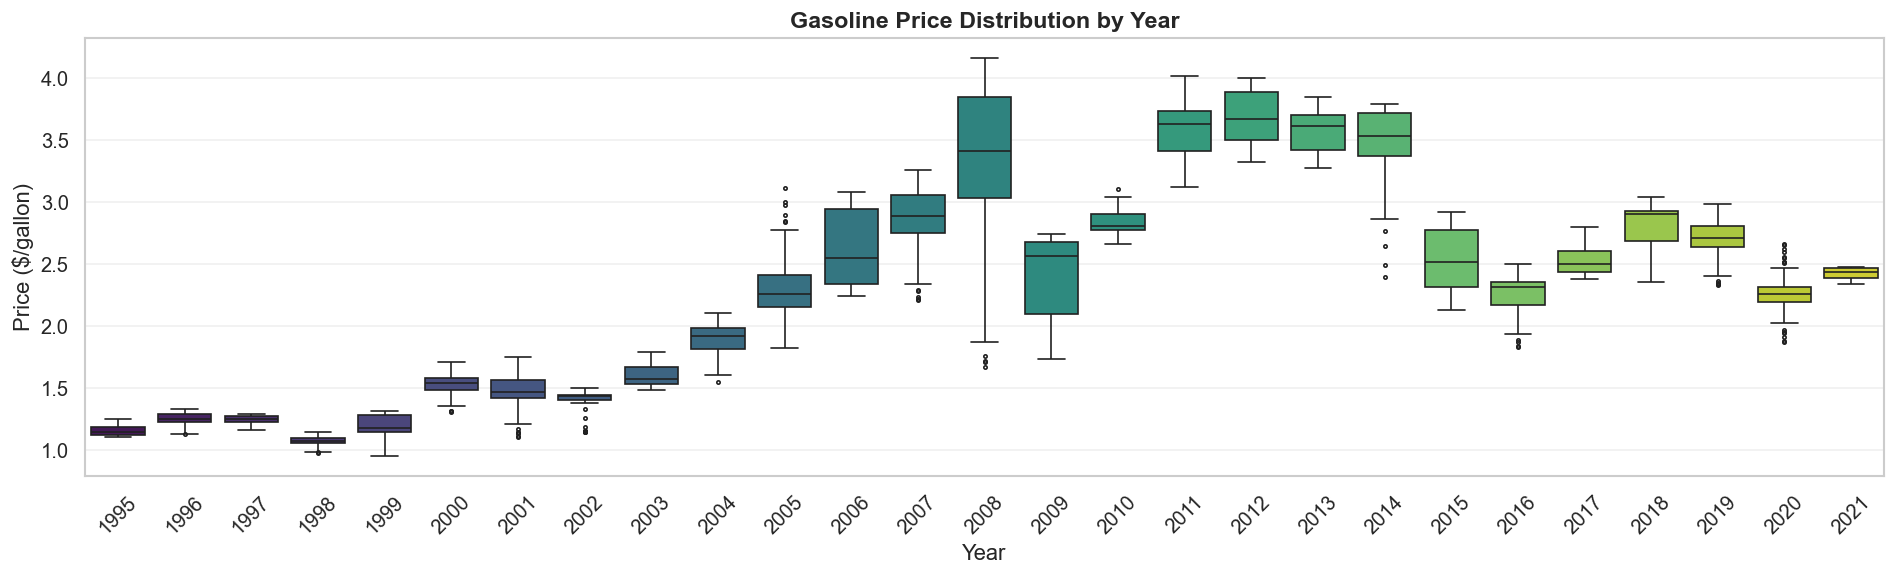

In [12]:
df_plot = df.copy()
df_plot['Year'] = df_plot['Date'].dt.year

fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df_plot, x='Year', y='A1', ax=ax, palette='viridis', fliersize=2)
ax.set_title('Gasoline Price Distribution by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price ($/gallon)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4.5 Weekly Price Change Distribution

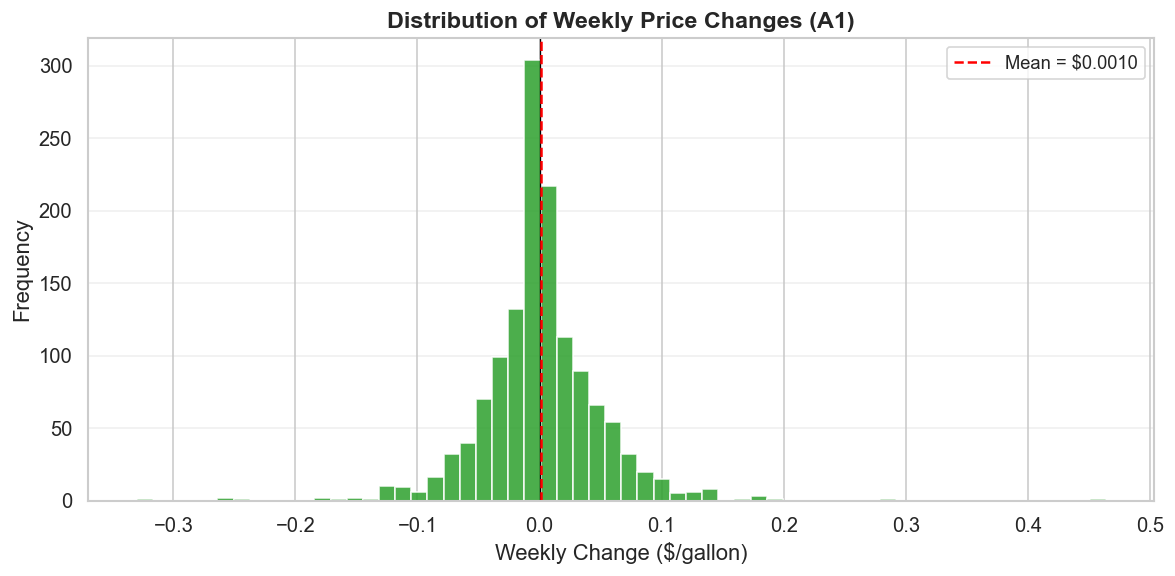

Mean weekly change  : $0.0010
Std of weekly change: $0.0488
Max weekly increase : $0.4640
Max weekly decrease : $-0.3300


In [13]:
price_changes = df['A1'].diff().dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(price_changes, bins=60, color='#2ca02c', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(price_changes.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean = ${price_changes.mean():.4f}")
ax.set_title('Distribution of Weekly Price Changes (A1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Weekly Change ($/gallon)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Mean weekly change  : ${price_changes.mean():.4f}")
print(f"Std of weekly change: ${price_changes.std():.4f}")
print(f"Max weekly increase : ${price_changes.max():.4f}")
print(f"Max weekly decrease : ${price_changes.min():.4f}")

### 4.6 Rolling Volatility

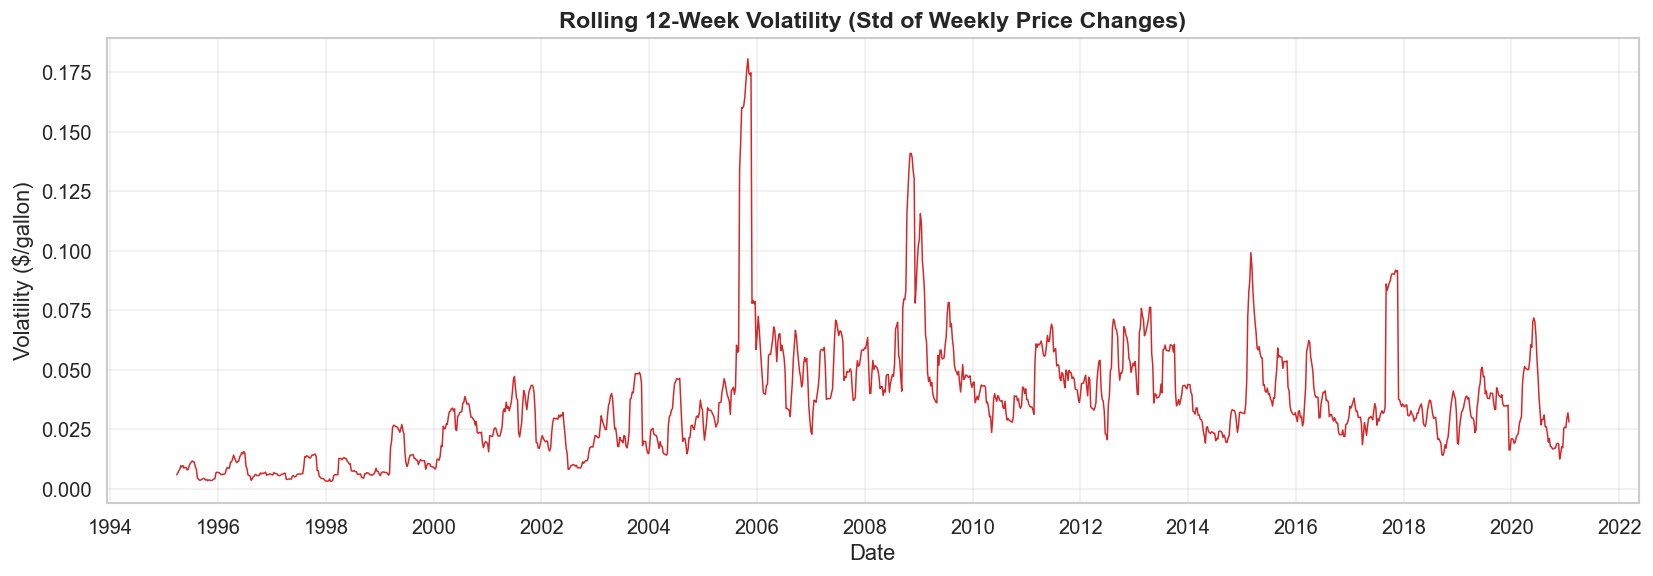

In [14]:
rolling_vol = price_changes.rolling(window=12).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'].iloc[1:], rolling_vol.values, color='#d62728', linewidth=0.9)
ax.set_title('Rolling 12-Week Volatility (Std of Weekly Price Changes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility ($/gallon)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.7 Price Chart with Volatile Periods Highlighted

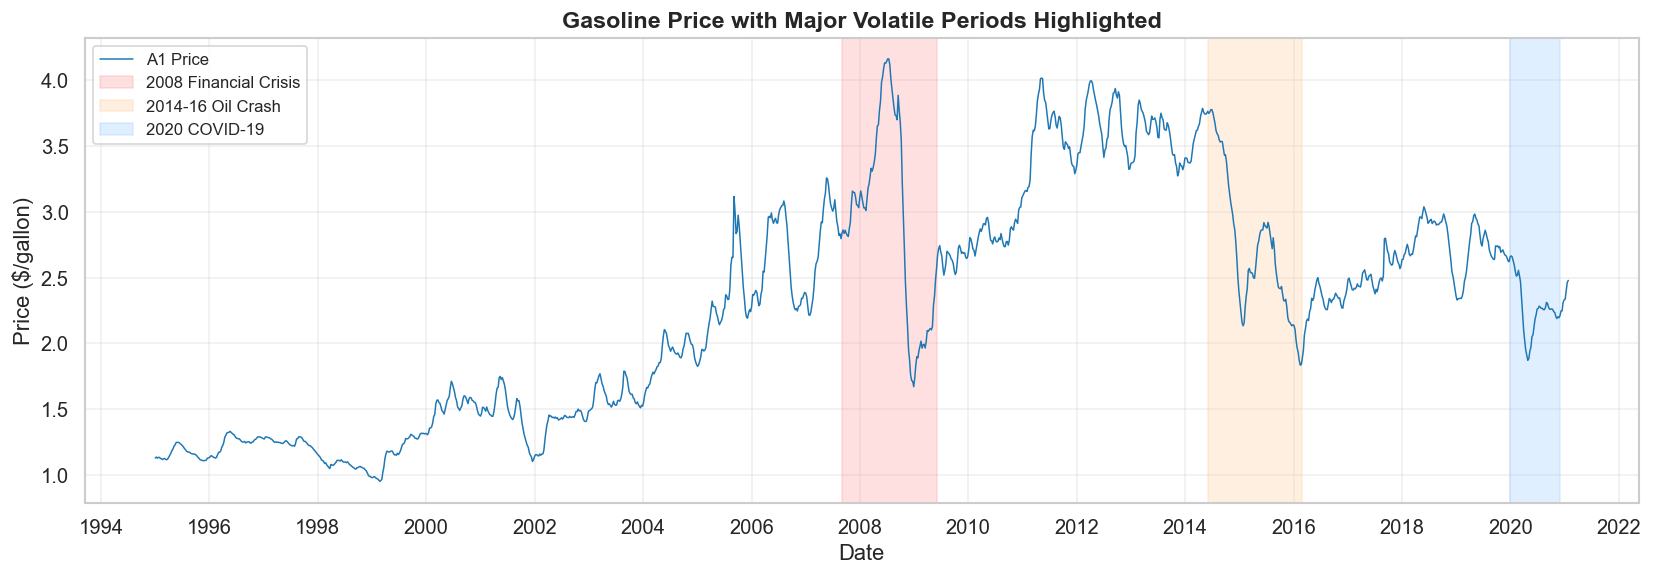

In [15]:
# Define notable volatile periods
volatile_periods = [
    ('2007-09-01', '2009-06-01', '2008 Financial Crisis', '#ff9999'),
    ('2014-06-01', '2016-03-01', '2014-16 Oil Crash', '#ffcc99'),
    ('2020-01-01', '2020-12-01', '2020 COVID-19', '#99ccff'),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['A1'], color='#1f77b4', linewidth=0.9, label='A1 Price')

for start, end, label, color in volatile_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.3, color=color, label=label)

ax.set_title('Gasoline Price with Major Volatile Periods Highlighted', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering

In [16]:
df_feat = data_utils.add_features(df.copy())
print(f"Shape after feature engineering: {df_feat.shape}")
print(f"\nNew columns added ({df_feat.shape[1] - df.shape[1]}):")
new_cols = [c for c in df_feat.columns if c not in df.columns]
for i, col in enumerate(new_cols, 1):
    print(f"  {i:2d}. {col}")

Shape after feature engineering: (1361, 40)

New columns added (26):
   1. A1_lag1
   2. A1_lag2
   3. A1_lag3
   4. A1_lag4
   5. A1_lag8
   6. A1_lag12
   7. A1_rolling_mean_4
   8. A1_rolling_std_4
   9. A1_rolling_mean_8
  10. A1_rolling_std_8
  11. A1_rolling_mean_12
  12. A1_rolling_std_12
  13. A1_diff_1
  14. A1_diff_4
  15. A1_pct_change_1
  16. A1_pct_change_4
  17. month
  18. quarter
  19. year
  20. week_of_year
  21. month_sin
  22. month_cos
  23. R1_lag1
  24. M1_lag1
  25. P1_lag1
  26. D1_lag1


In [17]:
df_feat.head()

,Date,A1,A2,A3,R1,R2,R3,M1,M2,M3,...,month,quarter,year,week_of_year,month_sin,month_cos,R1_lag1,M1_lag1,P1_lag1,D1_lag1
0,1995-01-02,1.127,1.104,1.231,1.079,1.063,1.167,1.170,1.159,1.298,...,1,1,1995,1,0.5,0.866025,NaN,NaN,NaN,NaN
1,1995-01-09,1.134,1.111,1.232,1.086,1.070,1.169,1.177,1.164,1.300,...,1,1,1995,2,0.5,0.866025,1.079,1.170,1.272,1.104
2,1995-01-16,1.126,1.102,1.231,1.078,1.062,1.169,1.168,1.155,1.299,...,1,1,1995,3,0.5,0.866025,1.086,1.177,1.279,1.102
3,1995-01-23,1.132,1.110,1.226,1.083,1.068,1.165,1.177,1.165,1.296,...,1,1,1995,4,0.5,0.866025,1.078,1.168,1.271,1.100
4,1995-01-30,1.131,1.109,1.221,1.083,1.068,1.162,1.176,1.163,1.291,...,1,1,1995,5,0.5,0.866025,1.083,1.177,1.277,1.095


### 5.1 Correlation Heatmap: Features vs Target (A1)

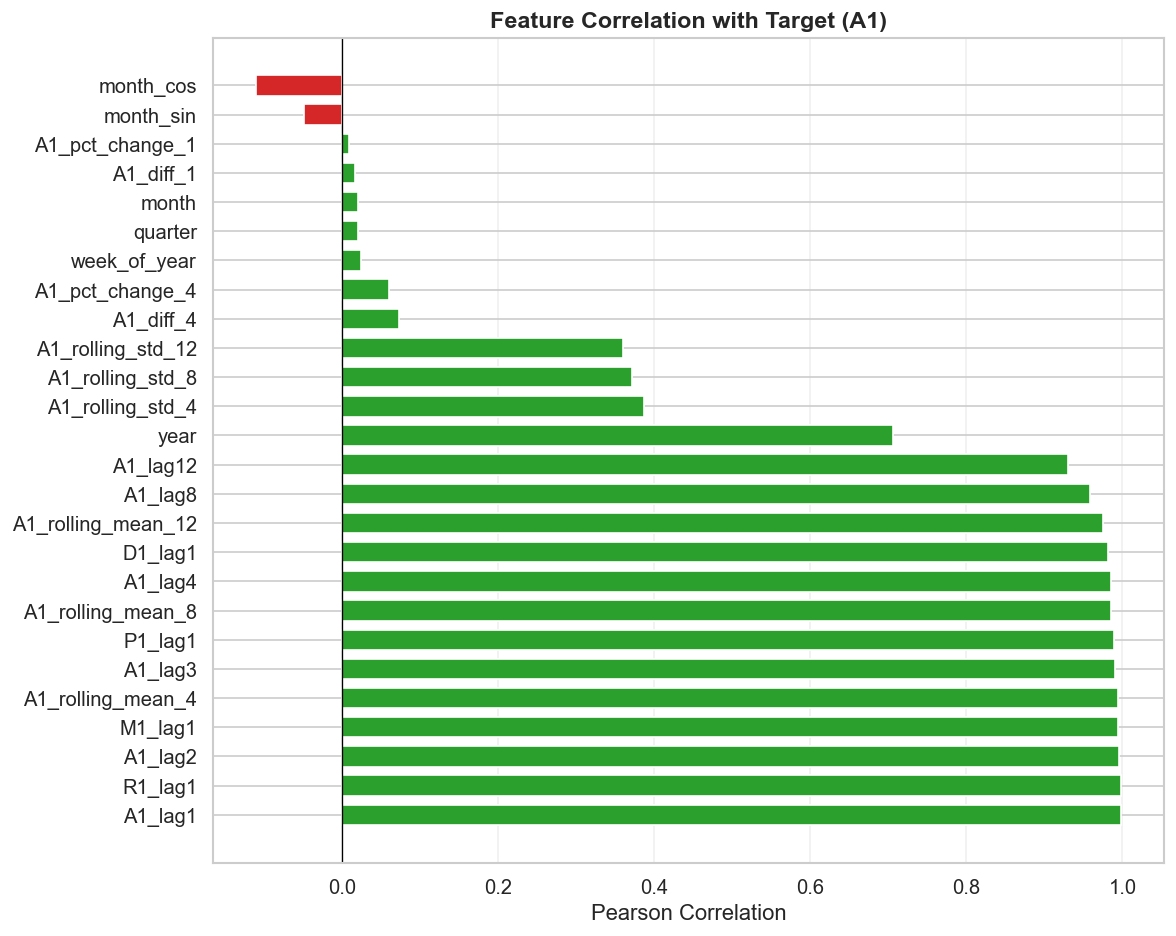

In [18]:
# Select engineered feature columns (exclude raw price and date columns)
feature_cols = [c for c in new_cols if c in df_feat.select_dtypes(include=[np.number]).columns]

corr_with_target = df_feat[feature_cols + ['A1']].corr()['A1'].drop('A1').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white', height=0.7)
ax.set_title('Feature Correlation with Target (A1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

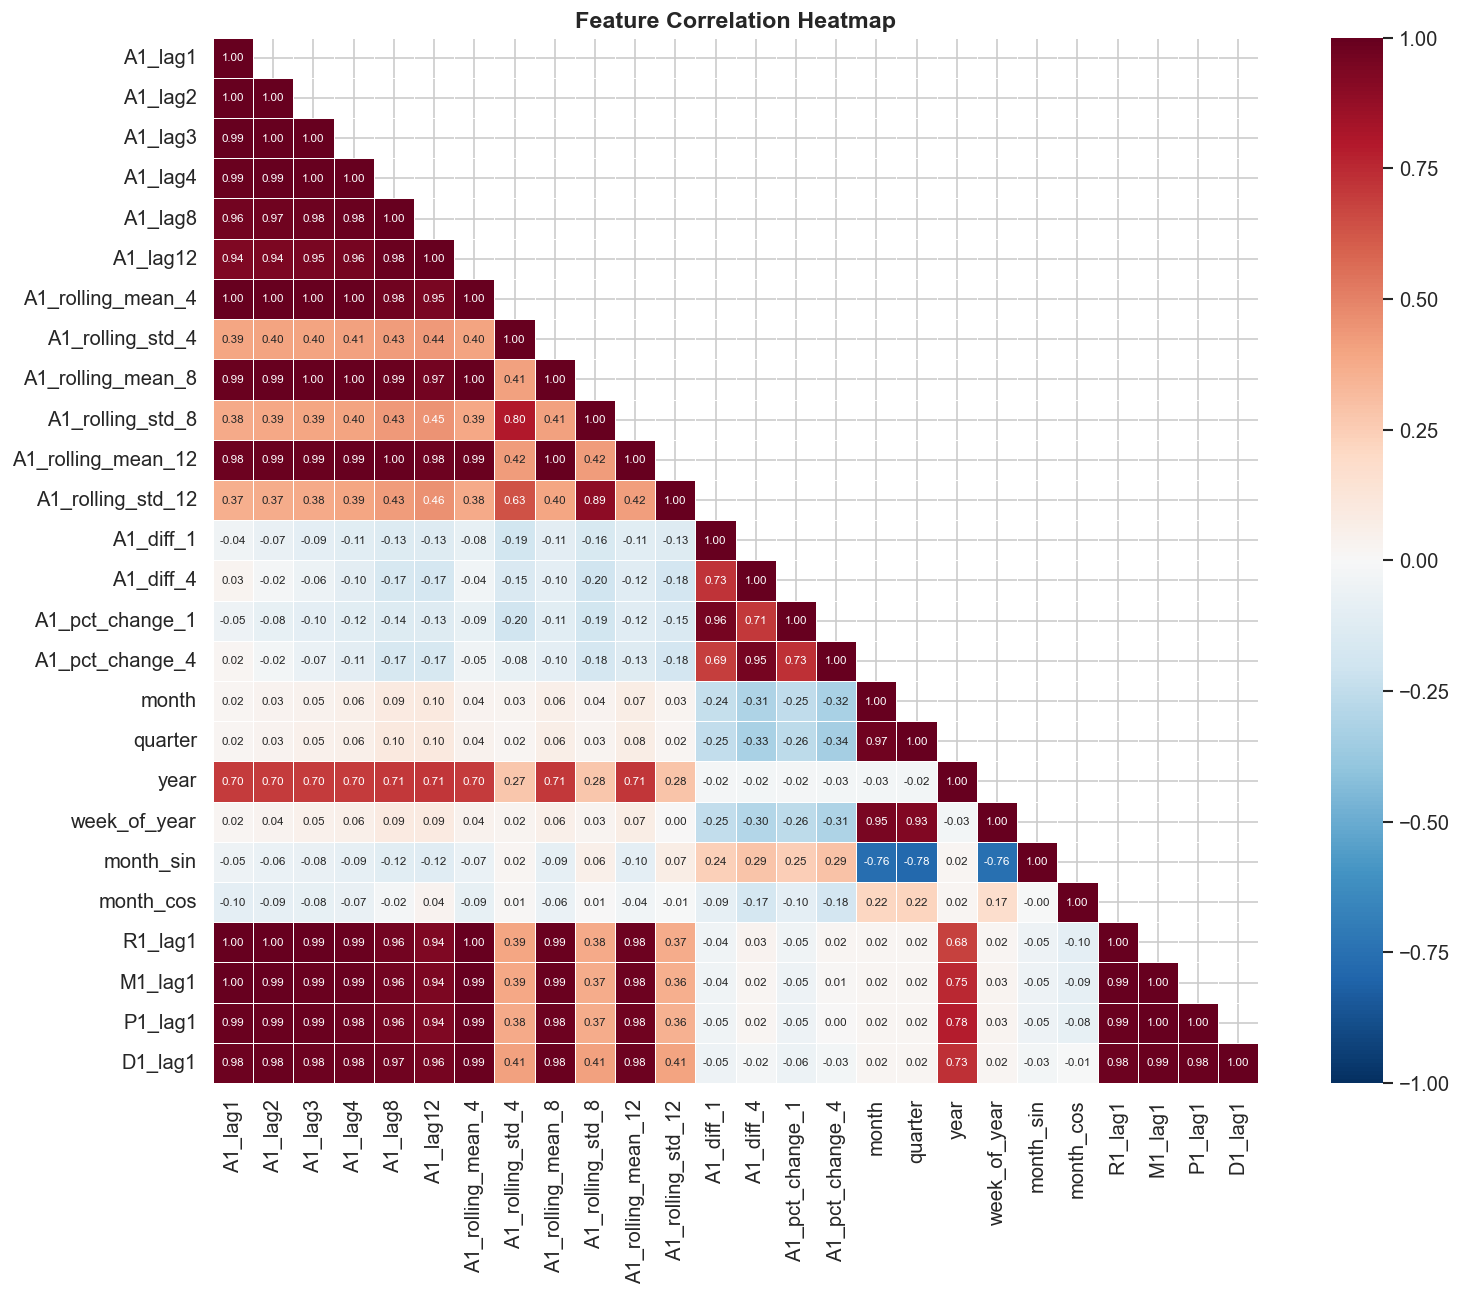

In [19]:
# Full feature correlation heatmap
corr_matrix = df_feat[feature_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Train / Validation / Test Split

In [20]:
# Create target (1-week-ahead forecast)
df_model = data_utils.create_target(df_feat, horizon=1)

# Drop rows with NaN from lag/rolling/target creation
df_model = df_model.dropna().reset_index(drop=True)
print(f"Rows available for modeling (after dropping NaN): {len(df_model)}")

# Split
train_df, val_df, test_df = data_utils.train_val_test_split(df_model)

print(f"\n{'Split':<10} {'Rows':>6}  {'Start':>12}  {'End':>12}")
print('-' * 48)
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{name:<10} {len(split_df):>6}  {split_df['Date'].min().strftime('%Y-%m-%d'):>12}  {split_df['Date'].max().strftime('%Y-%m-%d'):>12}")

Rows available for modeling (after dropping NaN): 1348

Split        Rows         Start           End
------------------------------------------------
Train         943    1995-03-27    2013-04-15
Val           202    2013-04-22    2017-02-27
Test          203    2017-03-06    2021-01-18


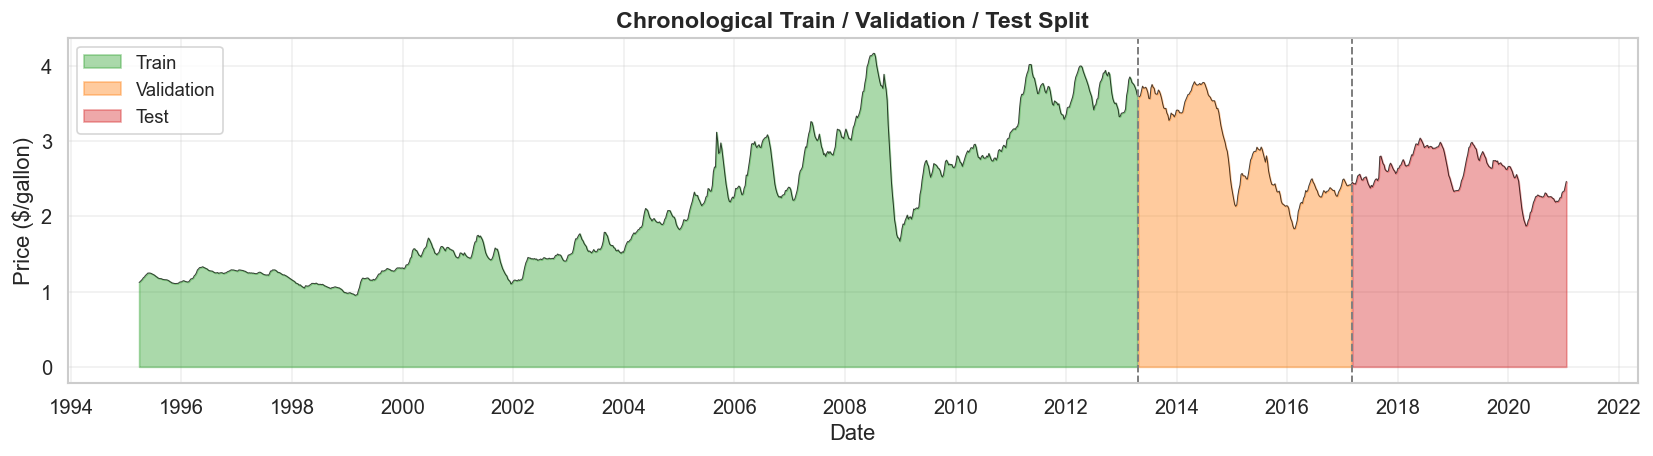

In [21]:
# Visualize the chronological split on a timeline
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(train_df['Date'], 0, train_df['A1'], alpha=0.4, color='#2ca02c', label='Train')
ax.fill_between(val_df['Date'], 0, val_df['A1'], alpha=0.4, color='#ff7f0e', label='Validation')
ax.fill_between(test_df['Date'], 0, test_df['A1'], alpha=0.4, color='#d62728', label='Test')

ax.plot(df_model['Date'], df_model['A1'], color='black', linewidth=0.6, alpha=0.7)

# Draw vertical boundary lines
ax.axvline(val_df['Date'].iloc[0], color='gray', linestyle='--', linewidth=1.2)
ax.axvline(test_df['Date'].iloc[0], color='gray', linestyle='--', linewidth=1.2)

ax.set_title('Chronological Train / Validation / Test Split', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Save Cleaned Data

In [22]:
cleaned_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'cleaned'))
os.makedirs(cleaned_dir, exist_ok=True)

# Save full processed dataframe
df_model.to_csv(os.path.join(cleaned_dir, 'gasoline_processed.csv'), index=False)

# Save individual splits
train_df.to_csv(os.path.join(cleaned_dir, 'train.csv'), index=False)
val_df.to_csv(os.path.join(cleaned_dir, 'val.csv'), index=False)
test_df.to_csv(os.path.join(cleaned_dir, 'test.csv'), index=False)

print(f"Saved processed data to: {cleaned_dir}")
print(f"  - gasoline_processed.csv  ({len(df_model)} rows)")
print(f"  - train.csv               ({len(train_df)} rows)")
print(f"  - val.csv                 ({len(val_df)} rows)")
print(f"  - test.csv                ({len(test_df)} rows)")

Saved processed data to: /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/data/cleaned
  - gasoline_processed.csv  (1348 rows)
  - train.csv               (943 rows)
  - val.csv                 (202 rows)
  - test.csv                (203 rows)


In [23]:
print("Notebook complete. Data is cleaned, explored, and ready for modeling.")

Notebook complete. Data is cleaned, explored, and ready for modeling.
